Implementing GMM in this notebook, Jupyter Notebook makes for easier testing. Once this is done, I can move it to a .py file so the GMM class can be imported into other parts of the repo. 

### CRITERIA

**Algorithm Implementation — 10%**

At least one algorithm from the course must be implemented without only being a wrapper around a library. For example, if implementing a mixture of Gaussians, you can’t use the scikit-learn implementation, but you can use numpy and torch.

- 10 pts: Algorithm is correctly implemented, produces reasonable outputs on the chosen dataset, and the team can explain implementation choices (e.g., choice of distance metric, number of clusters, regularization). The code matches what's being demoed.
- 8 pts: Implementation is correct but the team struggles to explain one design decision, or there is a minor bug that doesn't affect the demo materially.
- 4 pts: Algorithm is mostly a library call to scikit-learn or equivalent with a thin wrapper; the team cannot explain internals, or outputs are clearly wrong.
- 0 pts: The algorithm is entirely copy-pasted from an external source or repo without understanding.


In [1]:
# import libraries
import numpy as np
import torch
from torch.distributions import Normal, Independent
import matplotlib.pyplot as plt

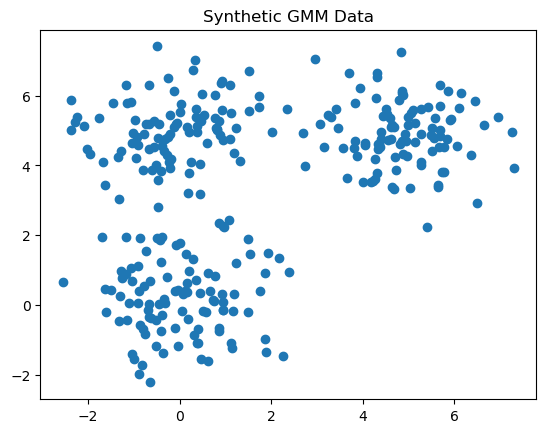

In [2]:
# make sample toy data
np.random.seed(0)

# create 3 gaussian clusters
mean1 = [0, 0]
mean2 = [5, 5]
mean3 = [0, 5]

cov = [[1, 0], [0, 1]]

X1 = np.random.multivariate_normal(mean1, cov, 100)
X2 = np.random.multivariate_normal(mean2, cov, 100)
X3 = np.random.multivariate_normal(mean3, cov, 100)

X = np.vstack([X1, X2, X3])

plt.scatter(X[:, 0], X[:, 1])
plt.title("Synthetic GMM Data")
plt.show()

### GMM Class (SCAFFOLD)

yap my understanding

- gmm is done by iterating between 2 steps (e-step ; maximization step)
- optimize these three things:
> - pi (prob of being in some class),
> - sigma (covariance matrix -- we are using DIAGONAL matrix, means you only store the variance of each dimension independently; shape (K,D) instead of (K,D,D)
> - mu

**Call heirarchy -- understanding how each function in the GMM class relates to one another:**

```
fit()                        ← call this from outside
 ├── _e_step()               ← called repeatedly inside fit's loop
 │    └── _compute_log_probs()   ← called inside _e_step
 ├── _m_step()               ← called repeatedly inside fit's loop
 └── _log_likelihood()       ← called inside fit to check convergence
      └── _compute_log_probs()   ← same helper, reused here

predict()                    ← you call this from outside
 └── _e_step()               ← reuses the same e-step

bic()                        ← you call this from outside
 └── _log_likelihood()       ← reuses the same log-likelihood
```

GMM is just iterating e-step --> maximization step.

In [6]:
# make GMM class 

class GMM:
    def __init__(self, K, max_iter=100, tol=1e-4, min_var=1e-6, device='cpu'):
        """
        Initialize the Gaussian Mixture Model.

        Parameters
        ----------
        K : int
            Number of Gaussian clusters to fit.
        max_iter : int
            Maximum number of EM iterations before stopping.
        tol : float
            Convergence threshold. Training stops when the change in
            log-likelihood between iterations is smaller than this value.
        min_var : float
            Minimum variance floor applied after every M-step to prevent
            cluster collapse (variance shrinking to zero).
        device : str
            PyTorch device string — 'cuda' if a GPU is available, else 'cpu'.

        Attributes set during fit()
        ---------------------------
        means : torch.Tensor, shape (K, D)
            Mean vector for each of the K Gaussian clusters.
        variances : torch.Tensor, shape (K, D)
            Per-dimension variance for each cluster (diagonal covariance).
        weights : torch.Tensor, shape (K,)
            Mixing weights — the prior probability of each cluster.
            Sums to 1.0.
        """
        self.k = K
        self.max_iter = max_iter
        self.tol = tol
        self.min_var = min_var
        self.device = device
        

    def fit(self):
        # training loop. initializes parameters, loops between E and M steps until convergence. like an environment or calling model.fit() 
        pass

    def _e_step(self):
        # given the current cluster parameters, how responsible is each cluster for each artwork?
        # input: all embeddings
        # output: matrix of shape (N, K) where each row sums to 1
        pass

    def _m_step(self):
        # given those responsibilities, what should the cluster parameters be?
        # does what: updates means, variances, and weights
        # 
        pass

    def compute_log_probs(self, X_t):
        # input: X_t shape (N, D)
        # output: shape (N, K) — log PDF of each point under each cluster
        # explanation: evaluates the Gaussian PDF for every point under every cluster
    
        # 0) initialize a list to collect one (N,) vector per cluster
        some_list = []
        
        # 1) for each cluster k in range(self.k):
        for k in range (self.k):
            # a) build a diagonal Gaussian from self.means[k] and self.variances[k]
            mean_k = self.mean[k]
            var_k = self.variances[k]
            std_k = torch.sqrt(var_k)

            # selfnote: Independent() bc it tells pytorch to treat all D dimensions as one joint event, 
            # so log_prob returns (N,) not (N, D)
            diag_gaussian = Independent(Normal(loc=mean_k, scale=std_k), 1)

            # b) evaluate log_prob for all N points -> (N,)
            log_probs_k = diag_gaussian.log_prob(X_t)  # (N,)

            # c) append to your list
            some_list.append(log_probs_k)

        # 2) stack the list into a single tensor → (N, K), and return 
        return torch.stack(some_list, dim=1) # this converts some_list to a proper tensor
        

    def predict(self):
        pass

    def _log_likelihood(self, X_t):
        pass

    def bic(self):
        pass